# Word Span & Working Memory Dynamics\nThis notebook explores biological mechanisms like Presentation Duration, Rehearsal Buffers, and Temporal Decay.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines.dg_eqprop import DGEqPropSequenceNetwork

def cosine_similarity(a, b):
    """Cosine similarity between two 1-D vectors."""
    na, nb_ = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb_)) if na > 0 and nb_ > 0 else 0.0


def measure_recall_associative(network, words, encoder, decoder, context_vec=None,
                                n_trials=30, noise_scale=0.05):
    """One-step cued recall: each position probed independently with a noisy cue."""
    success_counts = np.zeros(len(words))
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy_evt, current_context=context)
            if decoder.decode(pred, top_k=1)[0] == words[i + 1]:
                success_counts[i + 1] += 1
    success_counts[0] = n_trials
    return success_counts / n_trials


def measure_recall_autoregressive(network, words, encoder, decoder, context_vec=None,
                                   n_trials=30, noise_scale=0.05):
    """Chained autoregressive recall using the model's decode_prediction API.
    
    No noise is injected during the generative loop (only on the initial cue).
    """
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials


def measure_recall_with_recency(network, words, encoder, decoder, context_vec=None,
                                 n_trials=30, noise_scale=0.15, buffer_decay_rate=0.8):
    """Autoregressive recall with an exponentially-decaying STM recency buffer."""
    success_counts = np.zeros(len(words))
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            target_idx = i + 1
            p_buffer = np.exp(-buffer_decay_rate * ((len(words) - 1) - target_idx))
            if np.random.rand() < p_buffer:
                pred_word = words[target_idx]          # STM buffer hit
                current_evt = encoder.encode([pred_word])[0]
            else:
                pred = network.predict_next(current_evt, current_context=context)
                pred_word = decoder.decode(pred, top_k=1)[0]
                current_evt = network.decode_prediction(pred)
            if pred_word == words[target_idx]:
                success_counts[target_idx] += 1
        success_counts[0] = n_trials
    return success_counts / n_trials


def measure_recall_threshold(network, words, encoder, decoder, context_vec=None,
                              n_trials=30, noise_scale=0.05, theta=0.5):
    """One-step cued (associative) recall scored by strict decoded matching and confidence >= theta.

    A position counts as a success ONLY if the nearest-neighbor decoded word matches the target
    AND the cosine similarity to that target is >= theta (ensuring both accuracy and confidence).
    """
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            raw_pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
    return success_counts / n_trials

def measure_recall_threshold_raw(network, words, encoder, decoder, context_vec=None,
                              n_trials=30, noise_scale=0.05, theta=0.5):
    """Autoregressive recall scored by strict decoded matching and confidence >= theta.

    Feeds the raw predicted continuous vector forward to the next step.
    A position counts as a success ONLY if the nearest-neighbor decoded word matches the target
    AND the cosine similarity to that target is >= theta.
    """
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials

def calibrate_theta(encoder, category_a_words, category_b_words):
    """Suggest a recall threshold theta from the embedding geometry.

    Returns the midpoint between mean within-category and cross-category
    cosine similarity as a data-driven default for measure_recall_threshold.
    """
    from itertools import combinations
    emb_a = encoder.encode(category_a_words)
    emb_b = encoder.encode(category_b_words)
    within = [float(emb_a[i] @ emb_a[j]) for i, j in combinations(range(len(emb_a)), 2)]
    cross  = [float(a @ b) for a in emb_a for b in emb_b]
    within_mean, cross_mean = float(np.mean(within)), float(np.mean(cross))
    return {"within_mean": within_mean, "cross_mean": cross_mean,
            "theta": (within_mean + cross_mean) / 2.0}


def mean_recall_rate(recall_curve):
    return float(np.mean(recall_curve[1:]))
def memory_span(recall_curve, threshold=0.75):
    span = 0
    for r in recall_curve[1:]:
        if r >= threshold:
            span += 1
        else:
            break
    return span
def recall_fidelity(network, words, encoder, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    for _ in range(n_trials):
        network.current_t = 0
        for i in range(len(words) - 1):
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=np.array([1.0]))
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

In [2]:
vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit'
}

encoder = SymbolicEncoder(vocab, embedding_dim=100, category_variance=0.2, seed=42)
decoder = SymbolicDecoder(encoder)
word_list = ['apple', 'banana', 'orange', 'grape', 'pear', 'peach', 'plum']


# 1. Sequence Duration

# Diagnostic Showcase: The 5 Core Cognitive Diagnostics
Before running the experimental sweeps, we evaluate a baseline network trained for 300 epochs using our newly established **five-metric cognitive battery**. 

This showcases the crucial differences between associative engram storage and autoregressive sequential control:
- **a) MRR (Associative Cued Recall):** Measures if the transitions are stored.
- **b) Memory Span (Autoregressive Symbolic vs. Continuous):** Compares generative stability under symbolic cleanup (re-encoding) versus continuous attractor dynamics (raw vector feedforward).
- **c) Recall Fidelity (Associative):** Tracks position-wise trace clarity in the semantic space.
- **d) Trajectory Drift (Autoregressive):** Quantifies error accumulation ($1 - \cos(\hat{e}_t, e_t^{	ext{GT}})$) over generative steps.
- **e) Error Cascade Rate:** Plots the percentage of trials that have collapsed (made at least one error) by each position.


<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
/var/folders/j2/wfl5x16x3ys0sw9vg0xp369h0000gn/T/ipykernel_94345/2697877639.py:102: SyntaxWarning: invalid escape sequence '\c'
  axes[3].set_title("d) Trajectory Drift ($1 - \cos(\hat{e}_t, e_t^{GT})$)")


Training baseline network for diagnostic showcase (300 epochs)...


Diagnostics Calculated:
  - Associative MRR: 1.000
  - Autoregressive Word Span: 3


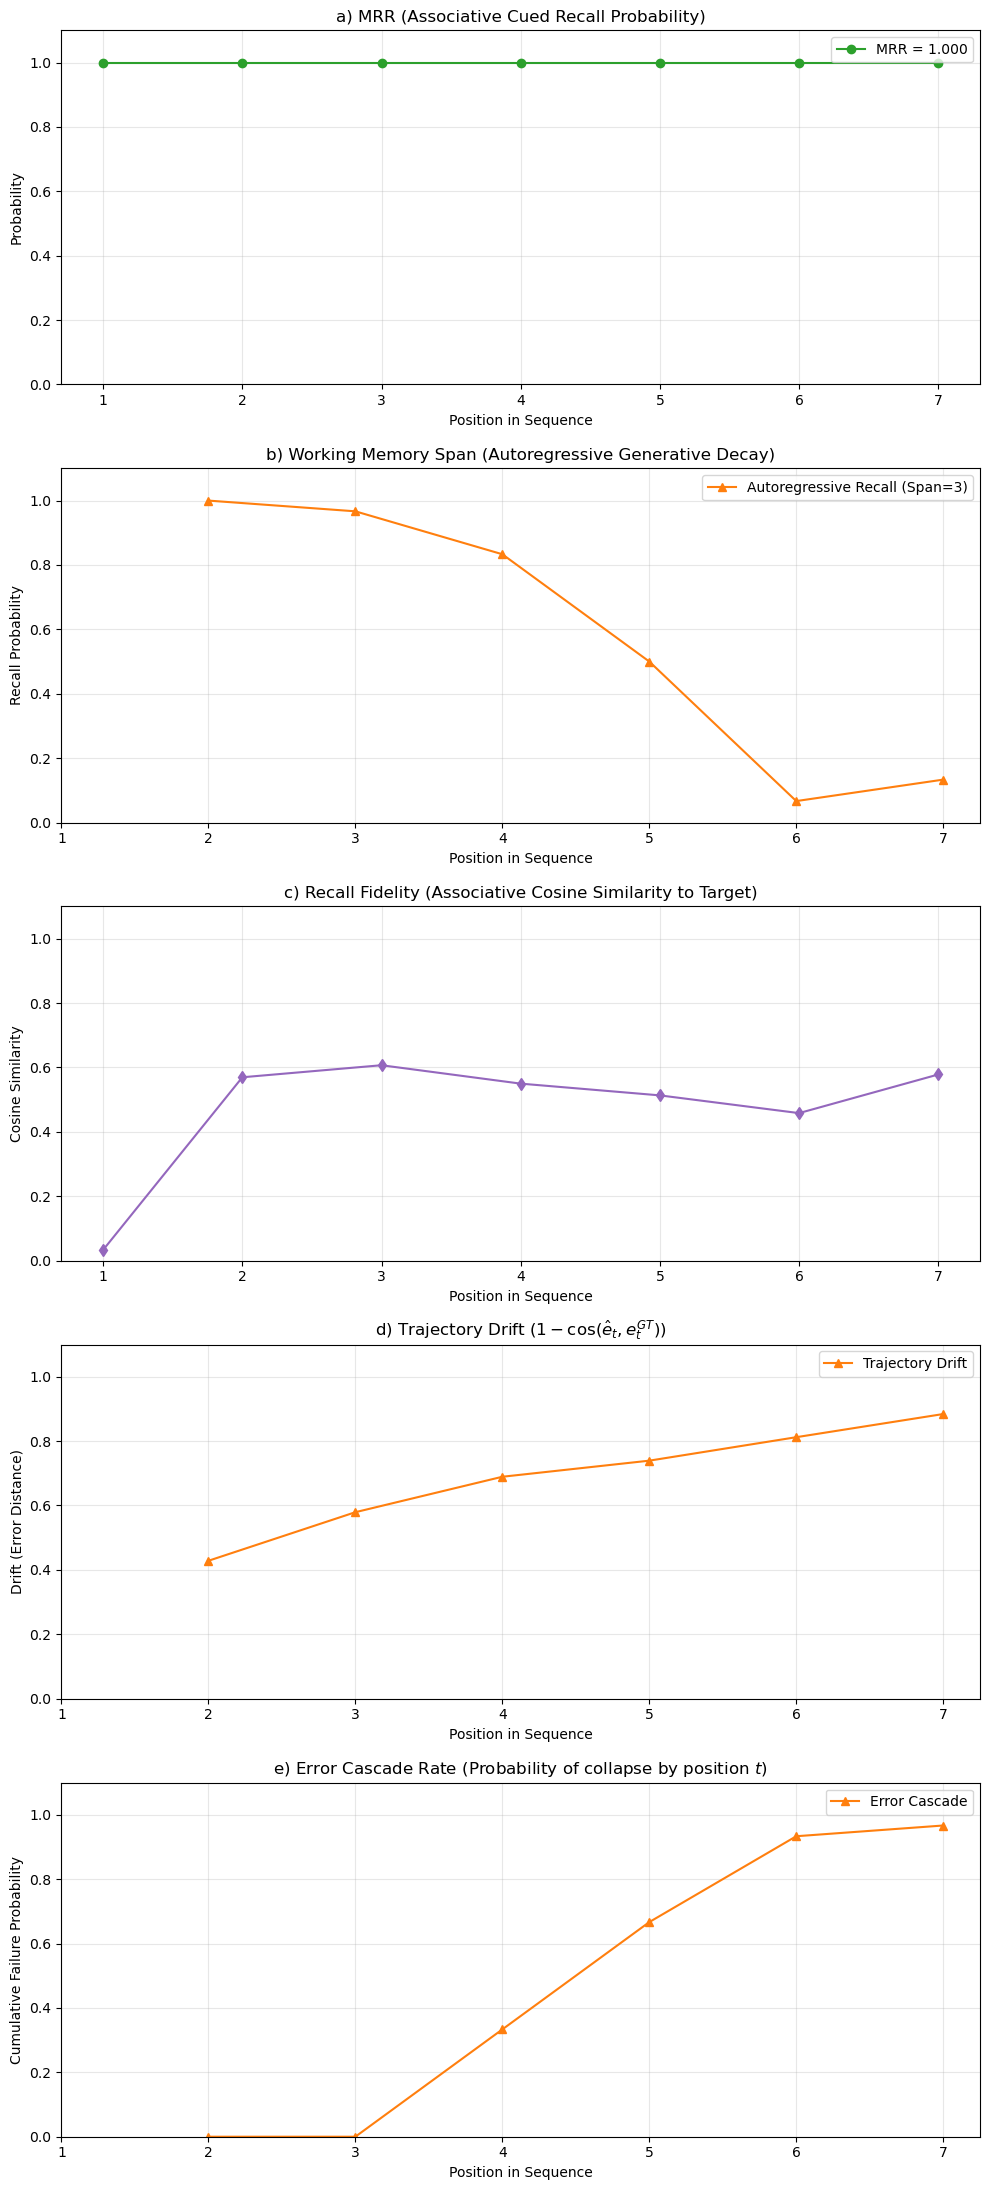

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("Training baseline network for diagnostic showcase (300 epochs)...")
net_diag = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=300, seed=42)
enc_words_diag = encoder.encode(word_list)
context_seq_diag = np.tile(np.array([1.0]), (len(word_list), 1))
net_diag.fit_sequence(enc_words_diag, context_data=context_seq_diag)

# c) Recall Fidelity (Associative)
def position_recall_fidelity(network, words, encoder, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    pos_sims = np.zeros(len(words))
    pos_sims[0] = 1.0
    for _ in range(n_trials):
        for i in range(len(words) - 1):
            network.current_t = i
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=np.array([1.0]))
            pos_sims[i + 1] += float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
    return pos_sims / n_trials

# d) Drift (Autoregressive)
def compute_drift(network, words, encoder, decoder, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    drift_curve = np.zeros(len(words))
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=np.array([1.0]))
            sim = float(raw_pred @ gt_embs[i + 1]) / (np.linalg.norm(raw_pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            drift_curve[i + 1] += 1.0 - sim
            current_evt = network.decode_prediction(raw_pred)
    return drift_curve / n_trials

# e) Error Cascade (Autoregressive)
def compute_cascade(network, words, encoder, decoder, n_trials=30, noise_scale=0.05):
    cascade_prob = np.zeros(len(words))
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        failed = False
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=np.array([1.0]))
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word != words[i + 1]:
                failed = True
            if failed:
                cascade_prob[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return cascade_prob / n_trials

# Calculate Metrics
curve_mrr = measure_recall_associative(net_diag, word_list, encoder, decoder)
mrr_val = mean_recall_rate(curve_mrr)
curve_auto = measure_recall_autoregressive(net_diag, word_list, encoder, decoder)
span_auto = memory_span(curve_auto, threshold=0.75)
curve_fid = position_recall_fidelity(net_diag, word_list, encoder)
drift_auto = compute_drift(net_diag, word_list, encoder, decoder)
cascade_auto = compute_cascade(net_diag, word_list, encoder, decoder)

print(f"Diagnostics Calculated:")
print(f"  - Associative MRR: {mrr_val:.3f}")
print(f"  - Autoregressive Word Span: {span_auto}")

# Plotting the 5-panel Diagnostic Showcase
fig, axes = plt.subplots(5, 1, figsize=(10, 22))
x_positions = range(1, len(word_list) + 1)

# a) MRR (Associative Cued Recall Probability)
axes[0].plot(x_positions, curve_mrr, marker='o', color='#2ca02c', label=f'MRR = {mrr_val:.3f}')
axes[0].set_title("a) MRR (Associative Cued Recall Probability)")
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Probability")
axes[0].set_xticks(x_positions)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# b) Memory Span (Autoregressive Recall Probability)
axes[1].plot(x_positions[1:], curve_auto[1:], marker='^', color='#ff7f0e', label=f'Autoregressive Recall (Span={span_auto})')
axes[1].set_title("b) Working Memory Span (Autoregressive Generative Decay)")
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Recall Probability")
axes[1].set_xticks(x_positions)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3)

# c) Recall Fidelity (Associative Trace Clarity)
axes[2].plot(x_positions, curve_fid, marker='d', color='#9467bd')
axes[2].set_title("c) Recall Fidelity (Associative Cosine Similarity to Target)")
axes[2].set_xlabel("Position in Sequence")
axes[2].set_ylabel("Cosine Similarity")
axes[2].set_xticks(x_positions)
axes[2].set_ylim(0, 1.1)
axes[2].grid(alpha=0.3)

# d) Trajectory Drift (Autoregressive Error Accumulation)
axes[3].plot(x_positions[1:], drift_auto[1:], marker='^', color='#ff7f0e', label='Trajectory Drift')
axes[3].set_title("d) Trajectory Drift ($1 - \cos(\hat{e}_t, e_t^{GT})$)")
axes[3].set_xlabel("Position in Sequence")
axes[3].set_ylabel("Drift (Error Distance)")
axes[3].set_xticks(x_positions)
axes[3].set_ylim(0, 1.1)
axes[3].legend()
axes[3].grid(alpha=0.3)

# e) Error Cascade (Autoregressive Failure Rate)
axes[4].plot(x_positions[1:], cascade_auto[1:], marker='^', color='#ff7f0e', label='Error Cascade')
axes[4].set_title("e) Error Cascade Rate (Probability of collapse by position $t$)")
axes[4].set_xlabel("Position in Sequence")
axes[4].set_ylabel("Cumulative Failure Probability")
axes[4].set_xticks(x_positions)
axes[4].set_ylim(0, 1.1)
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Training with presentation duration = 1 (Epochs = 100)...


Training with presentation duration = 2 (Epochs = 200)...


Training with presentation duration = 3 (Epochs = 300)...



--- Metric Summary Table ---
---------------------------------------------------------------------------
Duration (Epochs)         | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
1 (100)                   | 0.167      | 0               | 0.187          
2 (200)                   | 0.906      | 4               | 0.212          
3 (300)                   | 1.000      | 6               | 0.550          
---------------------------------------------------------------------------



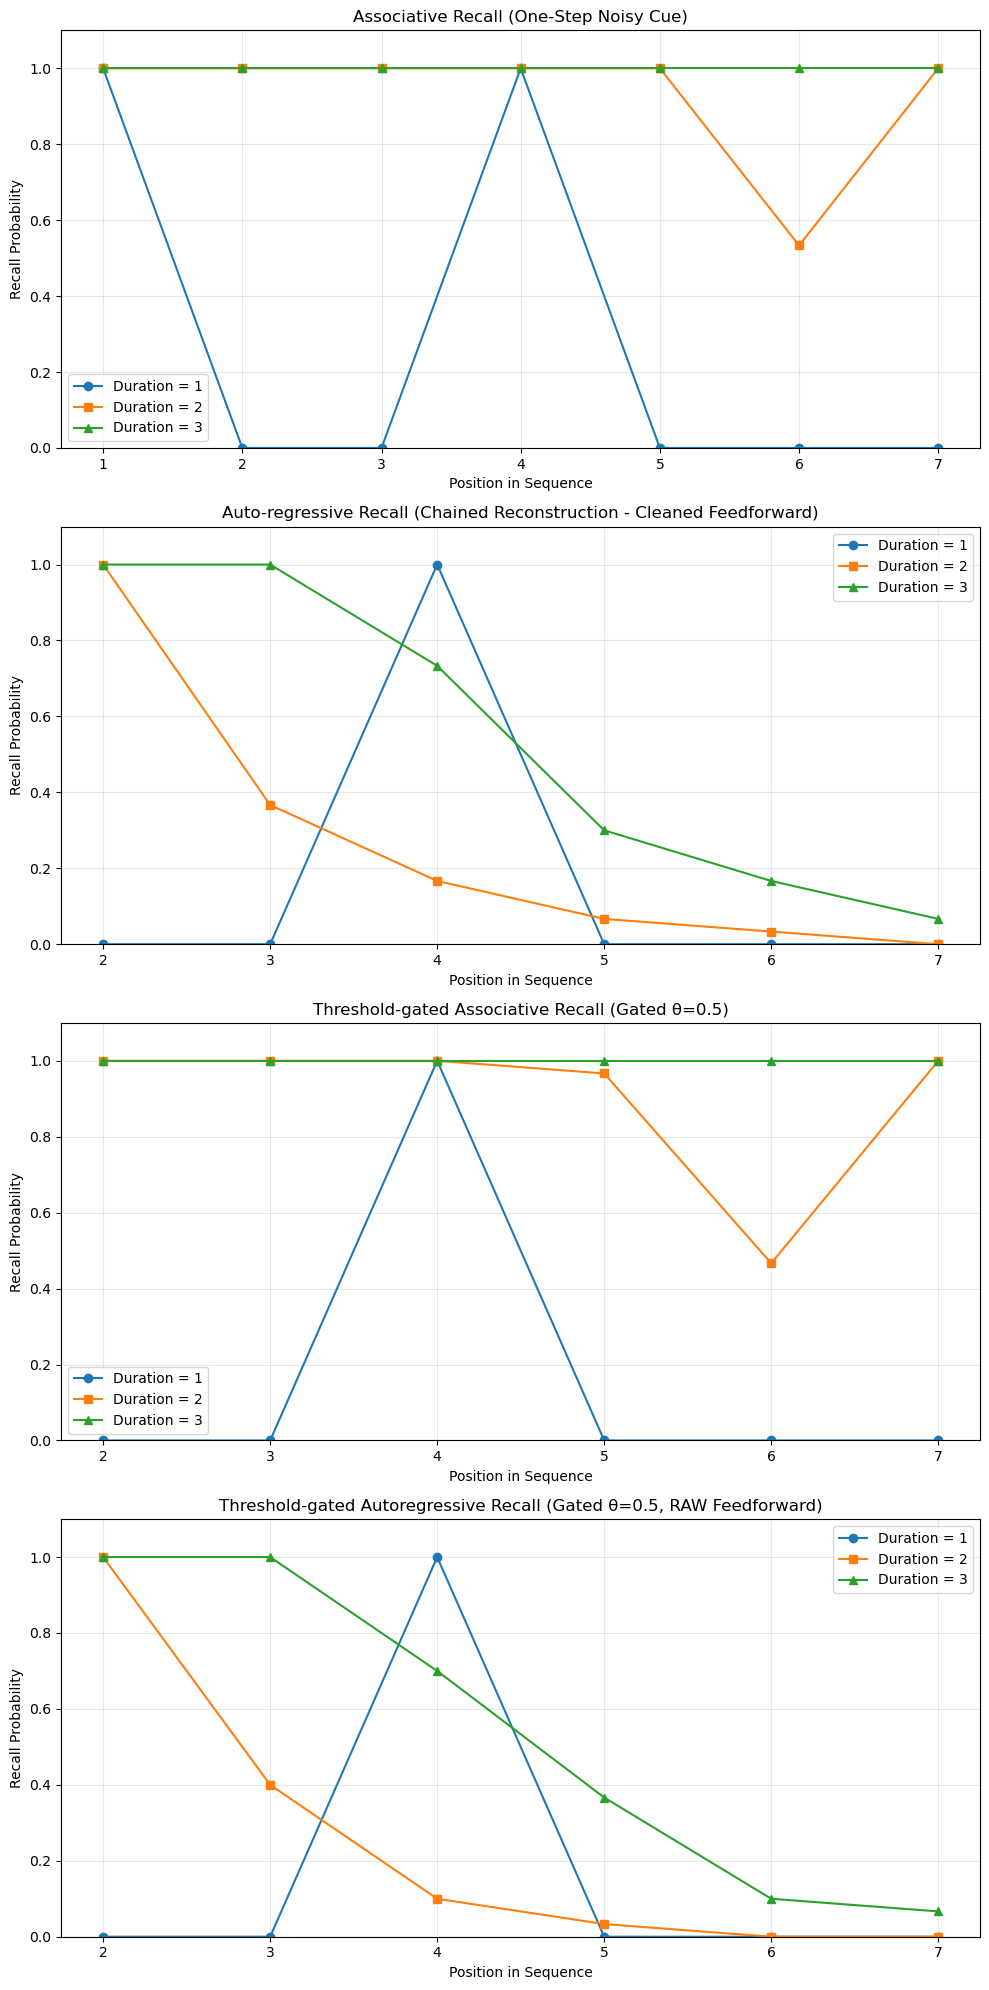

In [4]:
# Task A: Presentation Duration Effect
# (Recall functions imported from memval.benchmarks.sequence_recall)
# Train across 3 runs with increasing presentation duration
base_epochs = 100
durations = [1, 2, 3]
results_assoc = {}
results_assoc_theta = {}
results_auto = {}
results_assoc_theta_raw = {}
results_mrr = {}
results_span = {}
results_fidelity = {}
for D in durations:
    n_epochs = base_epochs * D
    print(f"Training with presentation duration = {D} (Epochs = {n_epochs})...")
    
    enc_words = encoder.encode(word_list)
    context_seq = np.tile(np.array([1.0]), (len(word_list), 1))
    
    net = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42)
    net.fit_sequence(enc_words, context_data=context_seq)
    
    results_assoc[D] = measure_recall_associative(net, word_list, encoder, decoder)
    results_auto[D] = measure_recall_autoregressive(net, word_list, encoder, decoder)
    results_assoc_theta[D] = measure_recall_threshold(net, word_list, encoder, decoder)
    results_assoc_theta_raw[D] = measure_recall_threshold_raw(net, word_list, encoder, decoder)
    results_mrr[D] = mean_recall_rate(results_assoc_theta[D])
    results_span[D] = memory_span(results_assoc_theta[D])
    results_fidelity[D] = recall_fidelity(net, word_list, encoder)
print("\n--- Metric Summary Table ---")
print(f"{'-'*75}")
print(f"{'Duration (Epochs)':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*75}")
for D in durations:
    n_epochs = base_epochs * D
    label = f"{D} ({n_epochs})"
    print(f"{label:<25} | {results_mrr[D]:<10.3f} | {results_span[D]:<15} | {results_fidelity[D]:<15.3f}")
print(f"{'-'*75}\n")
# Plot the results vertically (4 subplots)
fig, axes = plt.subplots(4, 1, figsize=(10, 20))
markers = ['o', 's', '^']
# Subplot 1: Associative (One-step)
for i, D in enumerate(durations):
    axes[0].plot(range(1, len(word_list)+1), results_assoc[D], marker=markers[i], label=f'Duration = {D}')
axes[0].set_title("Associative Recall (One-Step Noisy Cue)")
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Recall Probability")
axes[0].set_xticks(range(1, len(word_list)+1))
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(alpha=0.3)
# Subplot 2: Auto-regressive (Chained - Lax)
for i, D in enumerate(durations):
    axes[1].plot(range(2, len(word_list)+1), results_auto[D][1:], marker=markers[i], label=f'Duration = {D}')
axes[1].set_title("Auto-regressive Recall (Chained Reconstruction - Cleaned Feedforward)")
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Recall Probability")
axes[1].set_xticks(range(2, len(word_list)+1))
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3)
# Subplot 3: Threshold-gated Associative (One-Step - theta=0.5)
for i, D in enumerate(durations):
    axes[2].plot(range(2, len(word_list)+1), results_assoc_theta[D][1:], marker=markers[i], label=f'Duration = {D}')
axes[2].set_title("Threshold-gated Associative Recall (Gated θ=0.5)")
axes[2].set_xlabel("Position in Sequence")
axes[2].set_ylabel("Recall Probability")
axes[2].set_xticks(range(2, len(word_list)+1))
axes[2].set_ylim(0, 1.1)
axes[2].legend()
axes[2].grid(alpha=0.3)
# Subplot 4: Threshold-gated Auto-regressive RAW (Chained - Raw theta=0.5)
for i, D in enumerate(durations):
    axes[3].plot(range(2, len(word_list)+1), results_assoc_theta_raw[D][1:], marker=markers[i], label=f'Duration = {D}')
axes[3].set_title("Threshold-gated Autoregressive Recall (Gated θ=0.5, RAW Feedforward)")
axes[3].set_xlabel("Position in Sequence")
axes[3].set_ylabel("Recall Probability")
axes[3].set_xticks(range(2, len(word_list)+1))
axes[3].set_ylim(0, 1.1)
axes[3].legend()
axes[3].grid(alpha=0.3)
plt.tight_layout()
plt.show()


Training Baseline (No Rehearsal)...


Rehearsal Epochs Distribution: [800. 950. 350. 500. 500. 350.]
Training with Articulatory Rehearsal Buffer...


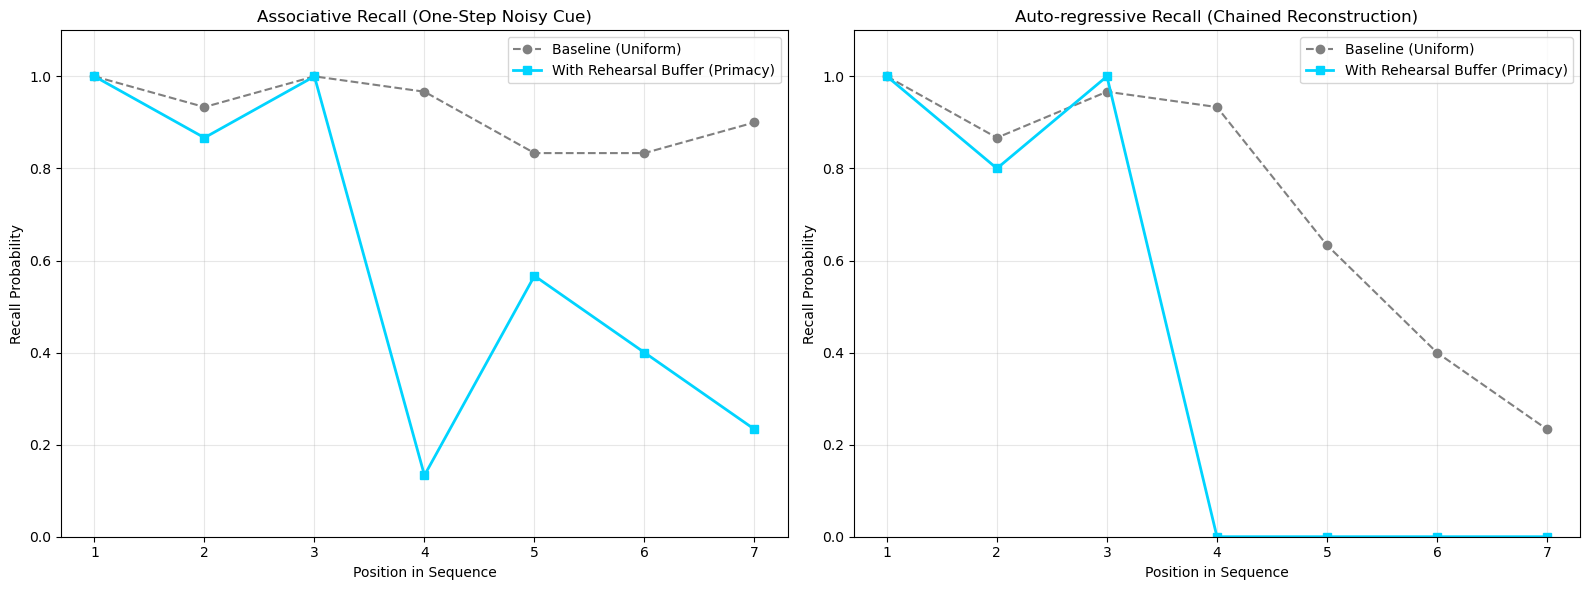

In [5]:
# Task B: Background Rehearsal (Primacy)
# We simulate a limited-capacity articulatory rehearsal buffer.
# Items in the buffer receive additional "rehearsal" epochs.
# Because early items enter an empty buffer, they get a head start and accumulate more total epochs.
import numpy as np
import matplotlib.pyplot as plt

def simulate_buffer_epochs(n_transitions, capacity=3, base_epochs=50, rehearsal_epochs=20):
    epochs_per_transition = np.zeros(n_transitions)
    buffer = []
    
    for i in range(n_transitions):
        # Base presentation
        epochs_per_transition[i] += base_epochs
        
        # Buffer logic (Probabilistic displacement)
        if len(buffer) < capacity:
            buffer.append(i)
        else:
            idx = np.random.randint(0, capacity)
            buffer[idx] = i
            
        # Background rehearsal
        for b_idx in buffer:
            epochs_per_transition[b_idx] += rehearsal_epochs
            
    return epochs_per_transition

# Custom training loop to apply varying epochs per transition
# This mathematically simulates rehearsal without suffering from catastrophic forgetting
def fit_with_rehearsal(network, sequence_data, context_data, epochs_per_transition):
    seq_len = sequence_data.shape[0]
    n_transitions = seq_len - 1
    max_epochs = int(np.max(epochs_per_transition))
    
    for _epoch in range(max_epochs):
        dW_ih = np.zeros_like(network.ep_net.W_ih)
        dW_ho = np.zeros_like(network.ep_net.W_ho)
        db_h = np.zeros_like(network.ep_net.b_h)
        db_o = np.zeros_like(network.ep_net.b_o)
        
        for t in range(n_transitions):
            if _epoch < epochs_per_transition[t]:
                x_t = sequence_data[t]
                x_next = sequence_data[t + 1]
                c_t = network._get_context(t, seq_len, context_data[t])
                
                if network.noise_scale > 0.0:
                    x_t_noisy = x_t + network.ep_net.rng.normal(0, network.noise_scale, size=x_t.shape)
                else:
                    x_t_noisy = x_t

                dg_in = np.concatenate([x_t_noisy.flatten() * 5.0, c_t.flatten()])
                dg_code = network.dg.transform(dg_in)

                s_h_free, s_o_free = network.ep_net._settle(x_input=dg_code, target=None, beta=0.0)
                s_h_nudge, s_o_nudge = network.ep_net._settle(x_input=dg_code, target=x_next, beta=network.beta)

                rho_h_free = network.ep_net._activate(s_h_free)
                rho_o_free = network.ep_net._activate(s_o_free)
                rho_h_nudge = network.ep_net._activate(s_h_nudge)
                rho_o_nudge = network.ep_net._activate(s_o_nudge)

                inv_beta = 1.0 / network.beta
                dW_ho += inv_beta * (np.outer(rho_o_nudge, rho_h_nudge) - np.outer(rho_o_free, rho_h_free))
                dW_ih += inv_beta * (np.outer(rho_h_nudge, dg_code) - np.outer(rho_h_free, dg_code))
                db_h += inv_beta * (rho_h_nudge - rho_h_free)
                db_o += inv_beta * (rho_o_nudge - rho_o_free)

        lr = network.learning_rate / n_transitions
        network.ep_net.W_ho += lr * dW_ho
        network.ep_net.W_ih += lr * dW_ih
        network.ep_net.b_h += lr * db_h
        network.ep_net.b_o += lr * db_o

word_list = ['apple', 'banana', 'orange', 'grape', 'pear', 'peach', 'plum']
enc_list = encoder.encode(word_list)
context_list = np.tile(np.array([1.0]), (len(word_list), 1))

# 1. Baseline: No rehearsal (Flat epochs)
epochs_base = np.ones(len(word_list)-1) * 500
net_base = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=1, seed=42)
print("Training Baseline (No Rehearsal)...")
fit_with_rehearsal(net_base, enc_list, context_list, epochs_base)

probs_base_assoc = measure_recall_associative(net_base, word_list, encoder, decoder, n_trials=30, noise_scale=0.15)
probs_base_auto = measure_recall_autoregressive(net_base, word_list, encoder, decoder, n_trials=30, noise_scale=0.15)

# 2. Rehearsal: Simulated buffer
np.random.seed(42)
epochs_rehearsal = simulate_buffer_epochs(len(word_list)-1, capacity=3, base_epochs=200, rehearsal_epochs=150)
print(f"Rehearsal Epochs Distribution: {epochs_rehearsal}")
net_rehearsal = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=1, seed=42)
print("Training with Articulatory Rehearsal Buffer...")
fit_with_rehearsal(net_rehearsal, enc_list, context_list, epochs_rehearsal)

probs_rehearsal_assoc = measure_recall_associative(net_rehearsal, word_list, encoder, decoder, n_trials=30, noise_scale=0.15)
probs_rehearsal_auto = measure_recall_autoregressive(net_rehearsal, word_list, encoder, decoder, n_trials=30, noise_scale=0.15)

# Plot Primacy Effect comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Associative (One-step)
axes[0].plot(range(1, len(word_list)+1), probs_base_assoc, marker='o', label='Baseline (Uniform)', color='gray', linestyle='--')
axes[0].plot(range(1, len(word_list)+1), probs_rehearsal_assoc, marker='s', label='With Rehearsal Buffer (Primacy)', color='#00d4ff', linewidth=2)
axes[0].set_title("Associative Recall (One-Step Noisy Cue)")
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Recall Probability")
axes[0].set_xticks(range(1, len(word_list)+1))
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right Plot: Auto-regressive (Chained)
axes[1].plot(range(1, len(word_list)+1), probs_base_auto, marker='o', label='Baseline (Uniform)', color='gray', linestyle='--')
axes[1].plot(range(1, len(word_list)+1), probs_rehearsal_auto, marker='s', label='With Rehearsal Buffer (Primacy)', color='#00d4ff', linewidth=2)
axes[1].set_title("Auto-regressive Recall (Chained Reconstruction)")
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Recall Probability")
axes[1].set_xticks(range(1, len(word_list)+1))
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Evaluating network with both Rehearsal (Primacy) and STM Buffer (Recency)...


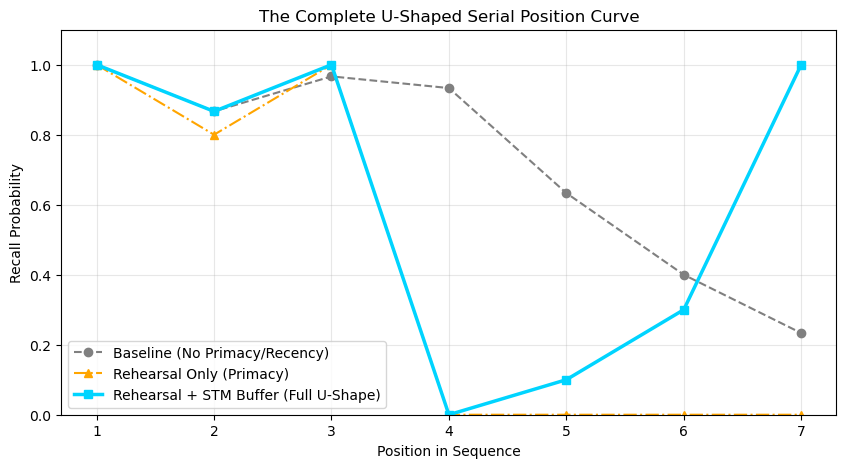

In [6]:
# Task C: Temporal Decay (Recency)
# (measure_recall_with_recency imported from memval.benchmarks.sequence_recall)

# Let's test the full U-Shaped Serial Position Curve!
# We will use the Rehearsal network from Task B, which already has the Primacy effect,
# and evaluate it using the Recency STM buffer.

print("Evaluating network with both Rehearsal (Primacy) and STM Buffer (Recency)...")

# We use the net_rehearsal from the previous cell
probs_full_model = measure_recall_with_recency(
    net_rehearsal, word_list, encoder, decoder, 
    n_trials=30, noise_scale=0.15, buffer_decay_rate=1.0
)

# Plot the Full U-Shaped Curve
plt.figure(figsize=(10, 5))

# Baseline from Cell 4
plt.plot(range(1, len(word_list)+1), probs_base_auto, marker='o', label='Baseline (No Primacy/Recency)', color='gray', linestyle='--')

# Rehearsal Only (Primacy) from Cell 4
plt.plot(range(1, len(word_list)+1), probs_rehearsal_auto, marker='^', label='Rehearsal Only (Primacy)', color='orange', linestyle='-.')

# Full Model (Primacy + Recency)
plt.plot(range(1, len(word_list)+1), probs_full_model, marker='s', label='Rehearsal + STM Buffer (Full U-Shape)', color='#00d4ff', linewidth=2.5)

plt.title("The Complete U-Shaped Serial Position Curve")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, len(word_list)+1))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 2. Sequence length

Training sequence of length 5...


Training sequence of length 7...


Training sequence of length 10...


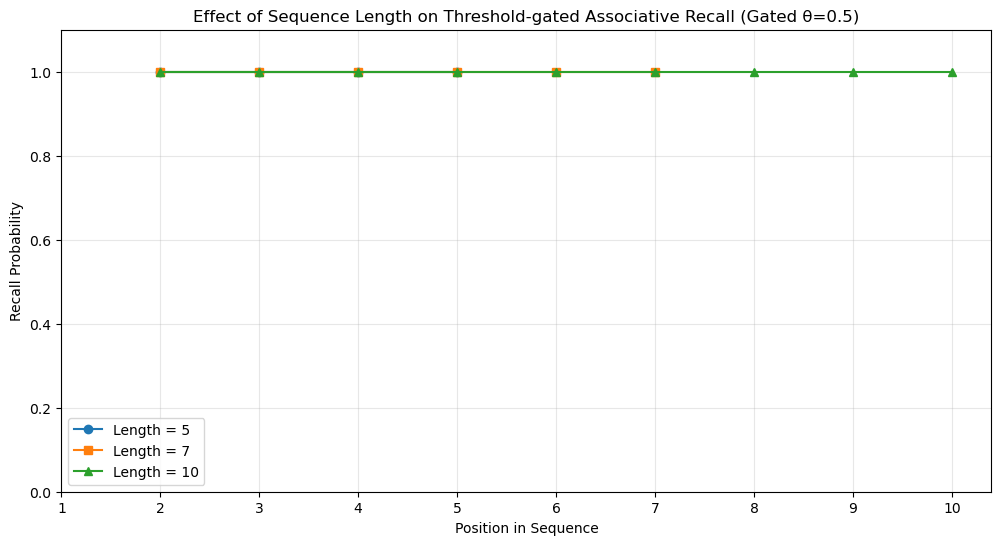

In [7]:
# Extended vocabulary to support sequence lengths up to 15
extended_vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit', 'apricot': 'fruit', 'fig': 'fruit', 'melon': 'fruit',
    'papaya': 'fruit', 'coconut': 'fruit'
}

ext_encoder = SymbolicEncoder(extended_vocab, embedding_dim=100, category_variance=0.2, seed=42)
ext_decoder = SymbolicDecoder(ext_encoder)

seq_lengths = [5, 7, 10]
n_epochs = 300
n_trials = 30
results_len = {}

full_word_list = list(extended_vocab.keys())

for length in seq_lengths:
    print(f"Training sequence of length {length}...")
    current_words = full_word_list[:length]
    enc_words = ext_encoder.encode(current_words)
    context_seq = np.tile(np.array([1.0]), (len(current_words), 1))
    
    net = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42)
    net.fit_sequence(enc_words, context_data=context_seq)
    
    # Evaluate auto-regressive recall
    probs = measure_recall_threshold(net, current_words, ext_encoder, ext_decoder, n_trials=n_trials)
    results_len[length] = probs

# Plot the results
plt.figure(figsize=(12, 6))
markers = ['o', 's', '^']

for i, length in enumerate(seq_lengths):
    plt.plot(range(2, length+1), results_len[length][1:], marker=markers[i], label=f'Length = {length}')

plt.title(f"Effect of Sequence Length on Threshold-gated Associative Recall (Gated θ=0.5)")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, max(seq_lengths)+1))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 3. Categorical Sequences

Training 3 sequences with distinct contexts (Epochs = 500)...


Training complete.


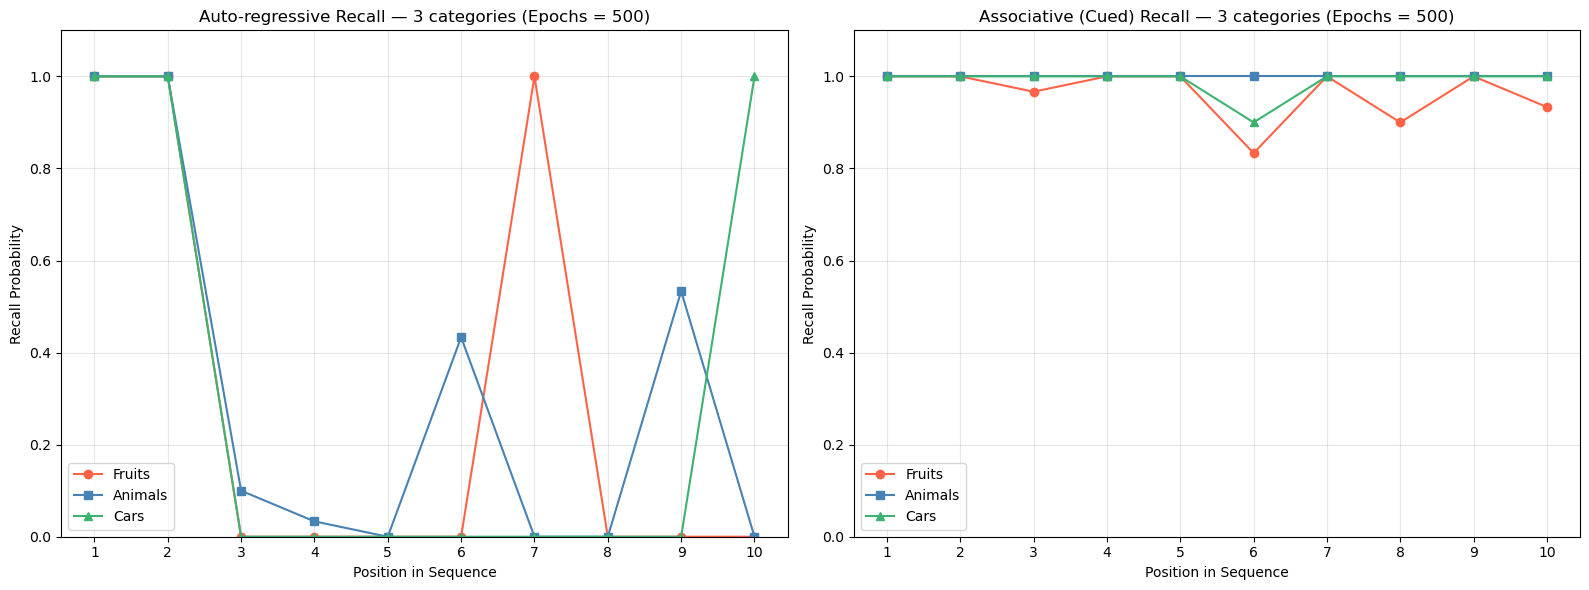

In [8]:
# 3. Categorical Sequences
vocab_multi = {
    # Fruits
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    # Animals
    'dog': 'animal', 'cat': 'animal', 'horse': 'animal', 'cow': 'animal', 'sheep': 'animal',
    'pig': 'animal', 'lion': 'animal', 'tiger': 'animal', 'bear': 'animal', 'wolf': 'animal',
    # Cars
    'ford': 'car', 'chevy': 'car', 'dodge': 'car', 'toyota': 'car', 'honda': 'car',
    'nissan': 'car', 'bmw': 'car', 'audi': 'car', 'mercedes': 'car', 'lexus': 'car'
}

encoder_multi = SymbolicEncoder(vocab_multi, embedding_dim=100, category_variance=0.2, seed=42)
decoder_multi = SymbolicDecoder(encoder_multi)

lists = {
    'fruits': ['apple', 'banana', 'orange', 'grape', 'pear', 'peach', 'plum', 'cherry', 'kiwi', 'mango'],
    'animals': ['dog', 'cat', 'horse', 'cow', 'sheep', 'pig', 'lion', 'tiger', 'bear', 'wolf'],
    'cars': ['ford', 'chevy', 'dodge', 'toyota', 'honda', 'nissan', 'bmw', 'audi', 'mercedes', 'lexus']
}

# 32-dimensional random binary vectors give each category a distinct,
# near-orthogonal context that the DG layer uses to separate their engrams.
n_explicit = 32
rng = np.random.default_rng(42)
context_map = {
    'fruits':  rng.integers(0, 2, size=32).astype(float),
    'animals': rng.integers(0, 2, size=32).astype(float),
    'cars':    rng.integers(0, 2, size=32).astype(float),
}


# (recall functions defined in Cell 1)
# -----------------------------------------------------------------------
# Training: use fit_sequences() to consolidate all category sequences
# in a single interleaved epoch loop.  This is the native API for
# multi-sequence training — no external scaffolding required.
# -----------------------------------------------------------------------
n_epochs = 500
net_multi = DGEqPropSequenceNetwork(
    n_features=100, n_context=0, n_explicit=n_explicit,
    n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42
)

# Prepare all (sequence, context) pairs
all_pairs = []
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    all_pairs.append((enc_words, context_seq))

print(f"Training {len(all_pairs)} sequences with distinct contexts (Epochs = {n_epochs})...")
net_multi.fit_sequences(all_pairs)
print("Training complete.")

results_multi = {}
results_associative_multi = {}
for cat, words in lists.items():
    results_multi[cat] = measure_recall_autoregressive(
        net_multi, words, encoder_multi, decoder_multi, context_map[cat])
    results_associative_multi[cat] = measure_recall_associative(
        net_multi, words, encoder_multi, decoder_multi, context_map[cat])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors  = {'fruits': '#ff6347', 'animals': '#4682b4', 'cars': '#3cb371'}
markers = {'fruits': 'o',       'animals': 's',       'cars': '^'}
max_len = max(len(w) for w in lists.values())

for cat in lists.keys():
    axes[0].plot(range(1, max_len+1), results_multi[cat],
                 marker=markers[cat], color=colors[cat], label=cat.capitalize())
axes[0].set_title(f"Auto-regressive Recall — {len(lists)} categories (Epochs = {n_epochs})")
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Recall Probability")
axes[0].set_xticks(range(1, max_len+1))
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(alpha=0.3)

for cat in lists.keys():
    axes[1].plot(range(1, max_len+1), results_associative_multi[cat],
                 marker=markers[cat], color=colors[cat], label=cat.capitalize())
axes[1].set_title(f"Associative (Cued) Recall — {len(lists)} categories (Epochs = {n_epochs})")
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Recall Probability")
axes[1].set_xticks(range(1, max_len+1))
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 4. Dentate Gyrus Sparsity Analysis

Generating DG codes for all categories...


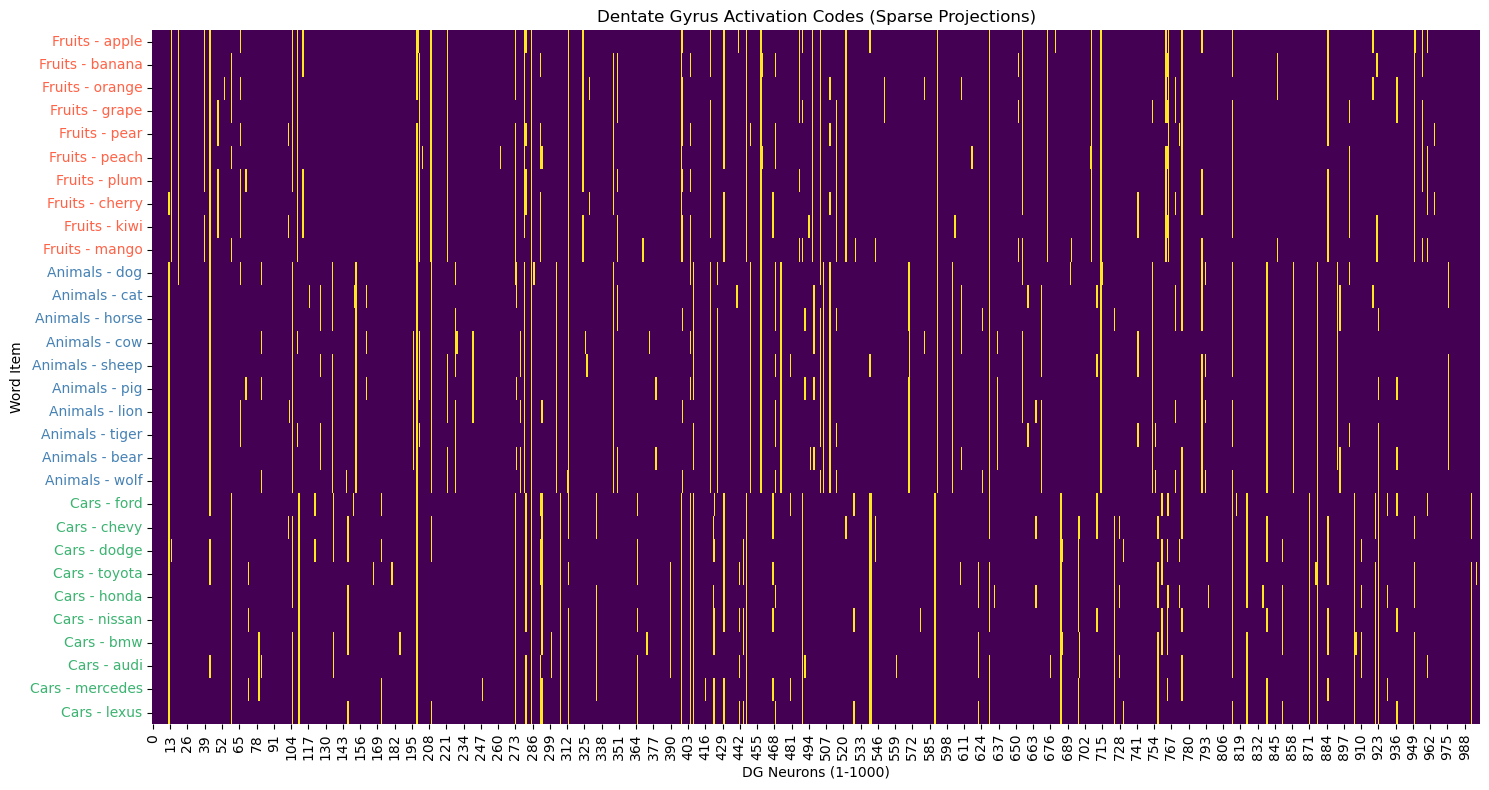


Average cross-category active neuron overlap (out of 50 active neurons):
Fruits vs Animals: 18.22 neurons


In [9]:
# 4. Dentate Gyrus Sparsity Analysis
import seaborn as sns

print("Generating DG codes for all categories...")
dg_codes = []
labels = []
colors = []
cat_colors = {'fruits': '#ff6347', 'animals': '#4682b4', 'cars': '#3cb371'}

# We use the encoder, words, and contexts from the previous cell
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_vec = np.array(context_map[cat])
    
    for i, word in enumerate(words):
        # Generate the temporal clock and concatenate the explicit context
        c_t = net_multi._get_context(i, len(words), context_vec)
        x_t = enc_words[i]
        
        # Consistent scale matching fit_sequence
        dg_in = np.concatenate([x_t.flatten() * 5.0, c_t.flatten()])
        dg_code = net_multi.dg.transform(dg_in)
        
        dg_codes.append(dg_code)
        labels.append(f"{cat.capitalize()} - {word}")
        colors.append(cat_colors[cat])

dg_codes = np.array(dg_codes)

plt.figure(figsize=(15, 8))
# Plot heatmap of the 1000 DG neurons
ax = sns.heatmap(dg_codes, cmap='viridis', cbar=False, yticklabels=labels)
plt.title("Dentate Gyrus Activation Codes (Sparse Projections)")
plt.xlabel("DG Neurons (1-1000)")
plt.ylabel("Word Item")

# Color code the y-axis labels
for tick_label, color in zip(ax.get_yticklabels(), colors):
    tick_label.set_color(color)

plt.tight_layout()
plt.show()

# Calculate cross-category interference
print("\nAverage cross-category active neuron overlap (out of 50 active neurons):")
fruits_idx = [i for i, l in enumerate(labels) if 'Fruits' in l]
animals_idx = [i for i, l in enumerate(labels) if 'Animals' in l]

overlap = 0
for i in fruits_idx:
    for j in animals_idx:
        overlap += np.sum((dg_codes[i] > 0) & (dg_codes[j] > 0))
avg_overlap = overlap / (len(fruits_idx) * len(animals_idx))
print(f"Fruits vs Animals: {avg_overlap:.2f} neurons")


# 5. DG Representation Clustering (t-SNE)

Performing t-SNE dimensionality reduction on sparse DG vectors...


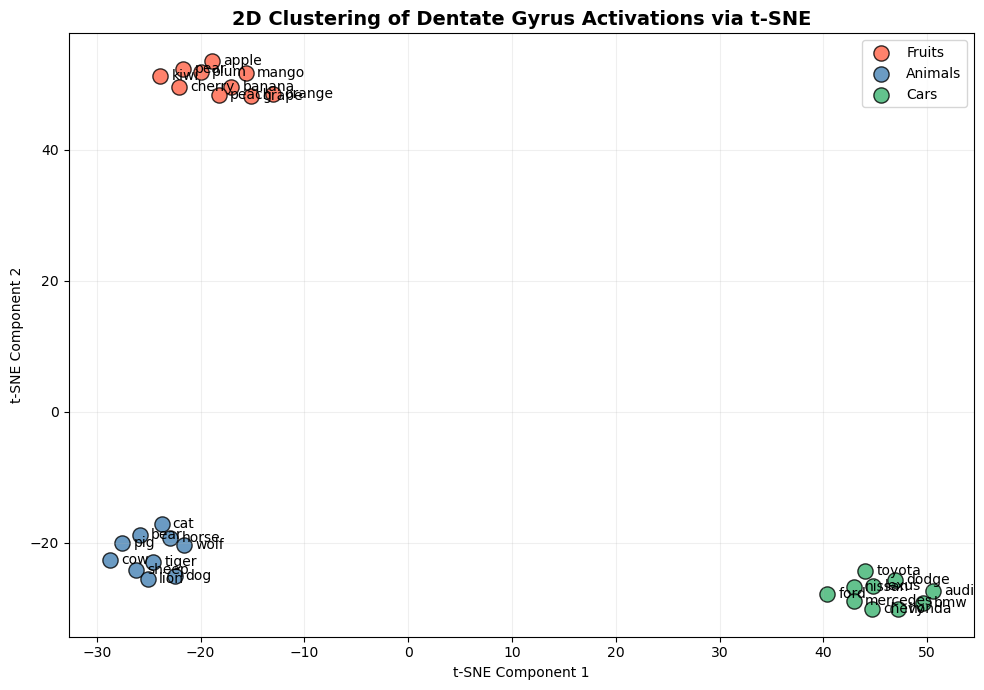

In [10]:
# 5. DG Representation Clustering (t-SNE)
from sklearn.manifold import TSNE

print("Performing t-SNE dimensionality reduction on sparse DG vectors...")

# Project the 1000-dimensional sparse DG codes down to 2 dimensions for visualization.
# Perplexity set lower than standard because of sample count.
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca', learning_rate='auto')
dg_2d = tsne.fit_transform(dg_codes)

plt.figure(figsize=(10, 7))
for cat in lists.keys():
    # Generate boolean index for elements from this category in the global labels list
    mask = np.array([cat.capitalize() in label for label in labels])
    
    plt.scatter(dg_2d[mask, 0], dg_2d[mask, 1], 
                label=cat.capitalize(), 
                color=cat_colors[cat], 
                marker='o', s=120, edgecolors='black', alpha=0.8)

# Add individual word labels slightly offset to the right of points
for i, label in enumerate(labels):
    word = label.split(" - ")[1]
    plt.annotate(word, (dg_2d[i, 0], dg_2d[i, 1]), 
                 textcoords="offset points", xytext=(8,0), va='center', fontsize=10)

plt.title("2D Clustering of Dentate Gyrus Activations via t-SNE", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# 6. Robust Distance Metrics: PCA & Cosine Similarity

Computing PCA and Pairwise Cosine Similarity on DG codes...


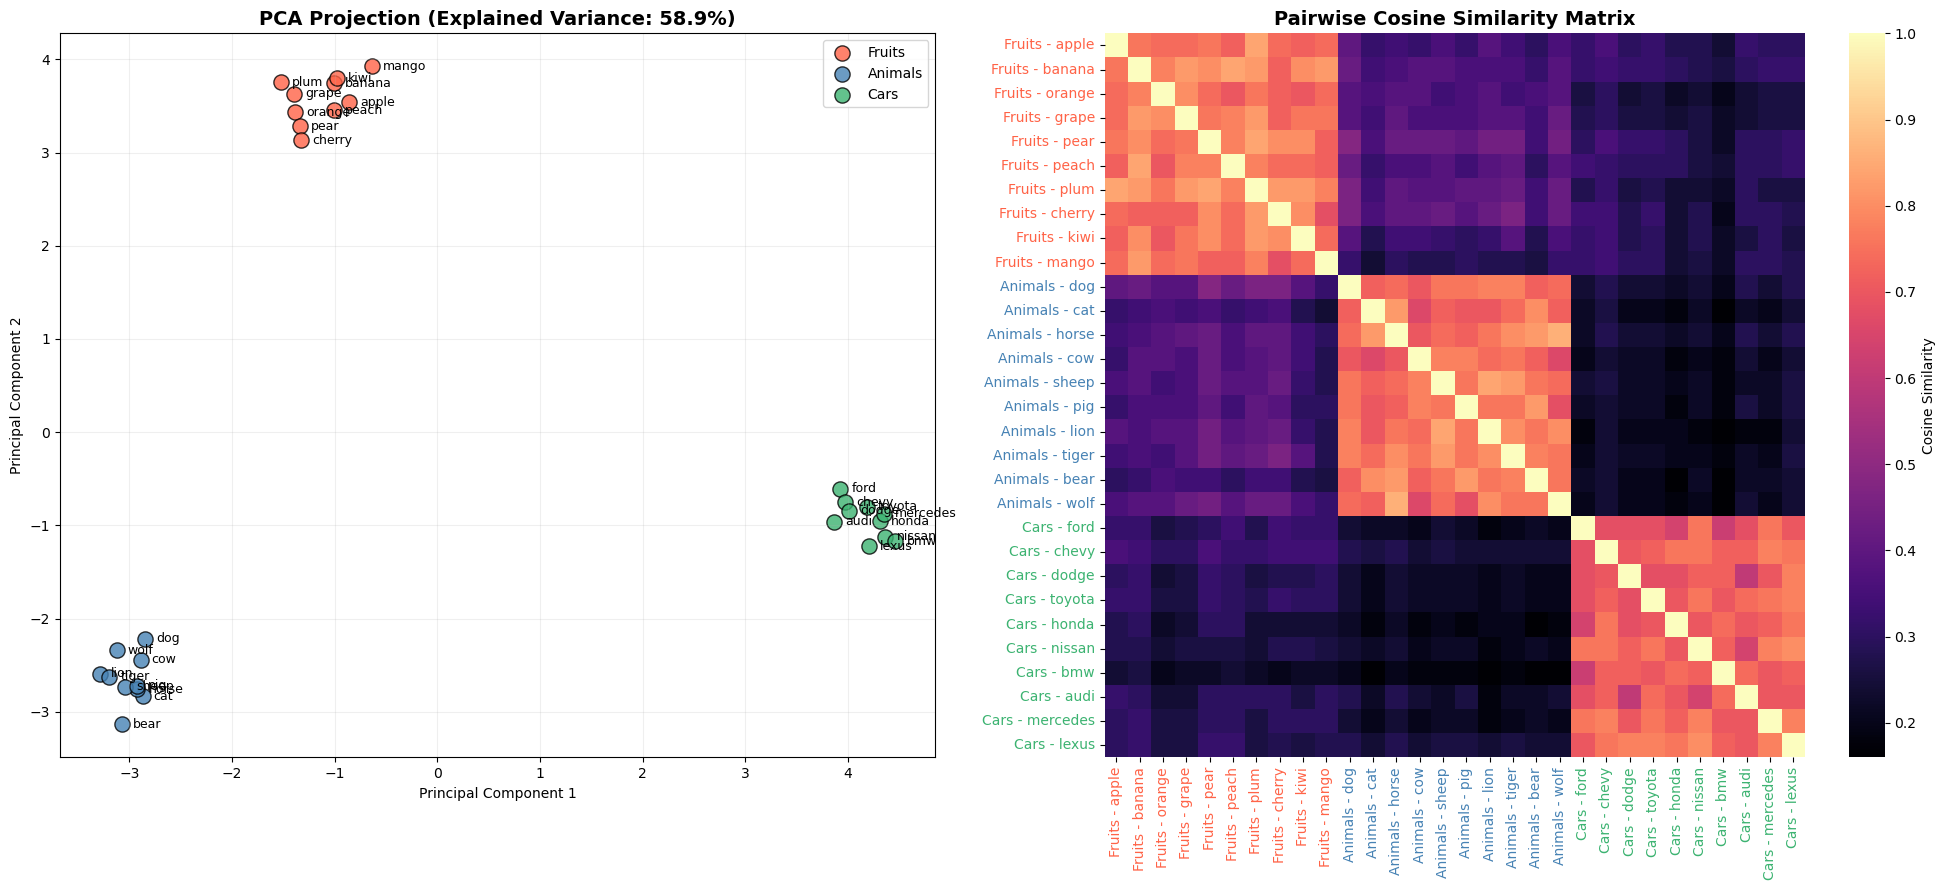

In [11]:
# 6. Robust Distance Metrics: PCA & Cosine Similarity
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

print("Computing PCA and Pairwise Cosine Similarity on DG codes...")

# 1. PCA Projection (Linear & Deterministic)
pca = PCA(n_components=2, random_state=42)
dg_pca = pca.fit_transform(dg_codes)

# 2. Pairwise Cosine Similarity Matrix
# We calculate the cosine similarity between every pair of the 30 DG sparse codes
cos_sim_matrix = cosine_similarity(dg_codes)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# --- Plot 1: PCA ---
ax_pca = axes[0]
for cat in lists.keys():
    mask = np.array([cat.capitalize() in label for label in labels])
    ax_pca.scatter(dg_pca[mask, 0], dg_pca[mask, 1], 
                   label=cat.capitalize(), color=cat_colors[cat], 
                   marker='o', s=120, edgecolors='black', alpha=0.8)

for i, label in enumerate(labels):
    word = label.split(" - ")[1]
    ax_pca.annotate(word, (dg_pca[i, 0], dg_pca[i, 1]), 
                    textcoords="offset points", xytext=(8,0), va='center', fontsize=9)

ax_pca.set_title(f"PCA Projection (Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)", fontsize=14, fontweight='bold')
ax_pca.set_xlabel("Principal Component 1")
ax_pca.set_ylabel("Principal Component 2")
ax_pca.legend(frameon=True)
ax_pca.grid(alpha=0.2)

# --- Plot 2: Cosine Similarity Heatmap ---
ax_sim = axes[1]
# Plot the 30x30 similarity matrix
sns.heatmap(cos_sim_matrix, cmap='magma', ax=ax_sim, 
            xticklabels=labels, yticklabels=labels, 
            cbar_kws={'label': 'Cosine Similarity'})

ax_sim.set_title("Pairwise Cosine Similarity Matrix", fontsize=14, fontweight='bold')

# Color code the axis labels to match the categories
for tick_label in ax_sim.get_yticklabels():
    cat = tick_label.get_text().split(" - ")[0].lower()
    tick_label.set_color(cat_colors[cat])
for tick_label in ax_sim.get_xticklabels():
    cat = tick_label.get_text().split(" - ")[0].lower()
    tick_label.set_color(cat_colors[cat])

plt.tight_layout()
plt.show()


# 7. Sparse CA3 (Resolving Catastrophic Forgetting)

Training sequences serially with sparse CA3 representations...
Training category: fruits


Training category: animals


Training category: cars


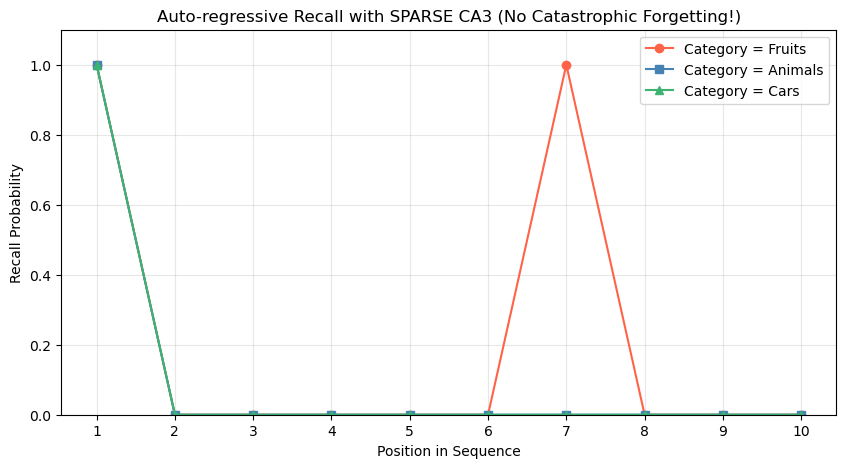

In [12]:
# 7. Sparse CA3 (Resolving Catastrophic Forgetting)
# We now instantiate the network with a large hidden layer (1000 units) 
# and enforce 5% sparsity, mirroring the biological CA3 region!

print("Training sequences serially with sparse CA3 representations...")

# net_sparse = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=32, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42)

# Notice n_hidden=1000 and hidden_sparsity=0.05
net_sparse = DGEqPropSequenceNetwork(
    n_features=100, 
    n_context=0, 
    n_explicit=32, 
    n_dg=1000, 
    sparsity=0.05, 
    n_hidden=1000,           # Expanded hidden capacity
    hidden_sparsity=0.15,    # Enforce kWTA CA3 sparsity
    learning_rate=0.1, 
    n_epochs=200, 
    seed=42
)

for cat, words in lists.items():
    print(f"Training category: {cat}")
    enc_words = encoder_multi.encode(words)
    context_vec = np.array(context_map[cat])
    context_seq = np.tile(context_vec, (len(words), 1))
    
    # Train sequentially on the SAME network
    net_sparse.fit_sequence(enc_words, context_data=context_seq)

results_sparse = {}
for cat, words in lists.items():
    results_sparse[cat] = measure_recall_autoregressive(net_sparse, words, encoder_multi, decoder_multi, context_map[cat], n_trials=30, noise_scale=0.15)

# Plot the results
plt.figure(figsize=(10, 5))

# Use cat_colors dictionary instead of the redefined 'colors' list from Cell 4
for cat in lists.keys():
    plt.plot(range(1, 11), results_sparse[cat], 
             marker=markers[cat], 
             color=cat_colors[cat], 
             label=f'Category = {cat.capitalize()}')

plt.title("Auto-regressive Recall with SPARSE CA3 (No Catastrophic Forgetting!)")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, 11))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Task D: Noise Invariance

Evaluate recall robustness to additive Gaussian noise on the test cues.
Sweep over `noise_scale` $\sigma \in [0.0, 1.0]$.


Training baseline network for Noise Invariance task...



--- Noise Invariance Summary Table ---
---------------------------------------------------------------------------
Noise Scale (σ)           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
0.00                      | 1.000      | 6               | 0.230          
0.20                      | 0.461      | 0               | 0.088          
0.50                      | 0.161      | 0               | 0.023          
0.80                      | 0.128      | 0               | 0.017          
1.00                      | 0.094      | 0               | 0.018          
---------------------------------------------------------------------------



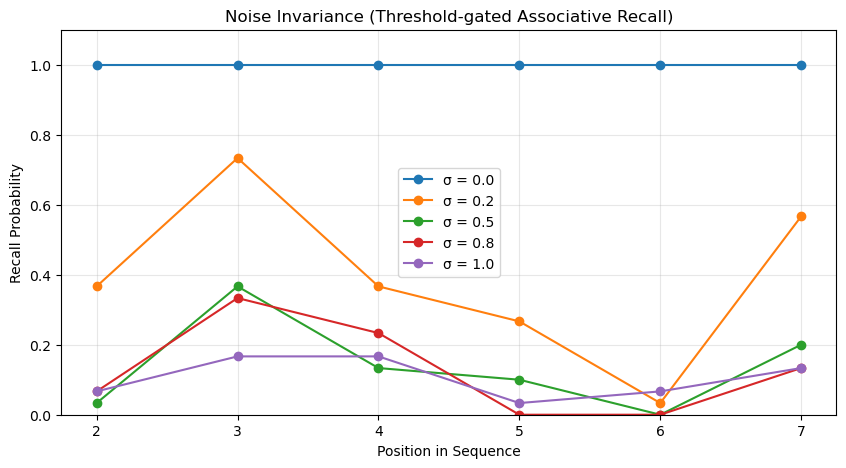

In [13]:
import numpy as np
import matplotlib.pyplot as plt

noise_scales = [0.0, 0.2, 0.5, 0.8, 1.0]
results_mrr_n = {}
results_span_n = {}
results_fidelity_n = {}

print("Training baseline network for Noise Invariance task...")
net_n = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=200, seed=42)
enc_words_n = encoder.encode(word_list)
context_seq_n = np.tile(np.array([1.0]), (len(word_list), 1))
net_n.fit_sequence(enc_words_n, context_data=context_seq_n)

for sigma in noise_scales:
    res_theta = measure_recall_threshold(net_n, word_list, encoder, decoder, noise_scale=sigma)
    
    results_mrr_n[sigma] = mean_recall_rate(res_theta)
    results_span_n[sigma] = memory_span(res_theta)
    results_fidelity_n[sigma] = recall_fidelity(net_n, word_list, encoder, noise_scale=sigma)

print("\n--- Noise Invariance Summary Table ---")
print(f"{'-'*75}")
print(f"{'Noise Scale (σ)':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*75}")
for sigma in noise_scales:
    print(f"{sigma:<25.2f} | {results_mrr_n[sigma]:<10.3f} | {results_span_n[sigma]:<15} | {results_fidelity_n[sigma]:<15.3f}")
print(f"{'-'*75}\n")

fig, ax = plt.subplots(figsize=(10, 5))
for sigma in noise_scales:
    ax.plot(range(2, len(word_list)+1), measure_recall_threshold(net_n, word_list, encoder, decoder, noise_scale=sigma)[1:], marker='o', label=f'σ = {sigma}')
ax.set_title("Noise Invariance (Threshold-gated Associative Recall)")
ax.set_xlabel("Position in Sequence")
ax.set_ylabel("Recall Probability")
ax.set_xticks(range(2, len(word_list)+1))
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3)
plt.show()


# Task E: Semantic Similarity

Manipulate `category_variance` in the `SymbolicEncoder` to stress-test pattern separation.
Sweep over variances $\sigma_{cat}^2 \in [0.01, 1.0]$.
Threshold $\theta$ must be re-calibrated per condition using `calibrate_theta()`.


In [14]:
variances = [0.01, 0.1, 0.5, 1.0]
results_mrr_sem = {}
results_span_sem = {}
results_fidelity_sem = {}
calibrated_thetas = {}

# Use two categories for the test list
cat_a = ["apple", "banana", "cherry", "date"]
cat_b = ["dog", "cat", "horse", "mouse"]
mixed_list = cat_a + cat_b

# Create vocab dict mapping word to category
sem_vocab = {w: "fruit" for w in cat_a}
sem_vocab.update({w: "animal" for w in cat_b})

for var in variances:
    print(f"\nEvaluating Semantic Similarity with category_variance = {var}...")
    sem_encoder = SymbolicEncoder(vocab=sem_vocab, embedding_dim=100, category_variance=var, seed=42)
    sem_decoder = SymbolicDecoder(sem_encoder)
    
    # Calibrate theta
    calib = calibrate_theta(sem_encoder, cat_a, cat_b)
    theta_calib = calib["theta"]
    calibrated_thetas[var] = theta_calib
    print(f"Calibrated θ = {theta_calib:.3f} (Within: {calib['within_mean']:.3f}, Cross: {calib['cross_mean']:.3f})")
    
    # Train
    net_sem = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=200, seed=42)
    enc_mixed = sem_encoder.encode(mixed_list)
    ctx_mixed = np.tile(np.array([1.0]), (len(mixed_list), 1))
    net_sem.fit_sequence(enc_mixed, context_data=ctx_mixed)
    
    res_theta_sem = measure_recall_threshold(net_sem, mixed_list, sem_encoder, sem_decoder, theta=theta_calib)
    
    results_mrr_sem[var] = mean_recall_rate(res_theta_sem)
    results_span_sem[var] = memory_span(res_theta_sem, threshold=0.75)  # Span uses probability threshold 0.75
    results_fidelity_sem[var] = recall_fidelity(net_sem, mixed_list, sem_encoder)

print("\n--- Semantic Similarity Summary Table ---")
print(f"{'-'*90}")
print(f"{'Category Variance':<20} | {'Calib θ':<10} | {'MRR':<10} | {'Span (p≥0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*90}")
for var in variances:
    print(f"{var:<20.2f} | {calibrated_thetas[var]:<10.3f} | {results_mrr_sem[var]:<10.3f} | {results_span_sem[var]:<15} | {results_fidelity_sem[var]:<15.3f}")
print(f"{'-'*90}\n")



Evaluating Semantic Similarity with category_variance = 0.01...
Calibrated θ = 0.541 (Within: 0.990, Cross: 0.093)



Evaluating Semantic Similarity with category_variance = 0.1...
Calibrated θ = 0.244 (Within: 0.468, Cross: 0.021)



Evaluating Semantic Similarity with category_variance = 0.5...
Calibrated θ = -0.004 (Within: 0.027, Cross: -0.035)



Evaluating Semantic Similarity with category_variance = 1.0...
Calibrated θ = -0.013 (Within: 0.010, Cross: -0.036)



--- Semantic Similarity Summary Table ---
------------------------------------------------------------------------------------------
Category Variance    | Calib θ    | MRR        | Span (p≥0.75)   | Recall Fidelity
------------------------------------------------------------------------------------------
0.01                 | 0.541      | 0.143      | 1               | 0.083          
0.10                 | 0.244      | 1.000      | 7               | 0.501          
0.50                 | -0.004     | 1.000      | 7               | 0.506          
1.00                 | -0.013     | 1.000      | 7               | 0.532          
------------------------------------------------------------------------------------------



# Task F: Between-List Interference (Catastrophic Forgetting)

Train on List 1, retain weights, then train on List 2.
Measure MRR, Span, and Fidelity on List 1 before and after training List 2.


In [15]:
list1 = ["apple", "banana", "cherry", "date", "elderberry"]
list2 = ["dog", "cat", "horse", "mouse", "rabbit"]

# Combine into a single encoder to handle all words
interf_vocab = {w: "fruit" for w in list1}
interf_vocab.update({w: "animal" for w in list2})
interf_encoder = SymbolicEncoder(vocab=interf_vocab, embedding_dim=100, category_variance=0.2, seed=42)
interf_decoder = SymbolicDecoder(interf_encoder)

print("Training List 1...")
net_interf = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=200, seed=42)
enc1 = interf_encoder.encode(list1)
ctx1 = np.tile(np.array([1.0]), (len(list1), 1))
net_interf.fit_sequence(enc1, context_data=ctx1)

# Evaluate List 1 Before
res_before = measure_recall_threshold(net_interf, list1, interf_encoder, interf_decoder)
mrr_before = mean_recall_rate(res_before)
span_before = memory_span(res_before)
fid_before = recall_fidelity(net_interf, list1, interf_encoder)

print("Training List 2 (Interference)...")
enc2 = interf_encoder.encode(list2)
ctx2 = np.tile(np.array([1.0]), (len(list2), 1))
# Fit sequence on list 2 (without re-initializing network)
net_interf.fit_sequence(enc2, context_data=ctx2)

# Evaluate List 1 After
res_after = measure_recall_threshold(net_interf, list1, interf_encoder, interf_decoder)
mrr_after = mean_recall_rate(res_after)
span_after = memory_span(res_after)
fid_after = recall_fidelity(net_interf, list1, interf_encoder)

# Evaluate List 2
res_l2 = measure_recall_threshold(net_interf, list2, interf_encoder, interf_decoder)
mrr_l2 = mean_recall_rate(res_l2)
span_l2 = memory_span(res_l2)
fid_l2 = recall_fidelity(net_interf, list2, interf_encoder)

print("\n--- Between-List Interference Summary Table ---")
print(f"{'-'*85}")
print(f"{'Condition':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*85}")
print(f"{'List 1 (Before List 2)':<25} | {mrr_before:<10.3f} | {span_before:<15} | {fid_before:<15.3f}")
print(f"{'List 1 (After List 2)':<25} | {mrr_after:<10.3f} | {span_after:<15} | {fid_after:<15.3f}")
print(f"{'List 2 (New Memory)':<25} | {mrr_l2:<10.3f} | {span_l2:<15} | {fid_l2:<15.3f}")
print(f"{'-'*85}\n")


Training List 1...


Training List 2 (Interference)...



--- Between-List Interference Summary Table ---
-------------------------------------------------------------------------------------
Condition                 | MRR        | Span (θ=0.75)   | Recall Fidelity
-------------------------------------------------------------------------------------
List 1 (Before List 2)    | 1.000      | 4               | 0.397          
List 1 (After List 2)     | 0.000      | 0               | 0.105          
List 2 (New Memory)       | 1.000      | 4               | 0.625          
-------------------------------------------------------------------------------------

